# Demo Chapter 7 — Mini Decoder-Only Transformer (LLM)

Notebook này bám sát các ý chính trong Chapter 7 của *Speech and Language Processing*:

- Language modeling = dự đoán token tiếp theo
- Pretraining trên văn bản thô
- Decoder-only Transformer với causal mask
- Cross-entropy loss và perplexity
- Autoregressive generation
- Prompting
- Greedy decoding, temperature sampling, top-k sampling

**Vì sao chọn kiến trúc này?**

Trong Chapter 7, kiến trúc phù hợp nhất để demo LLM là **decoder-only Transformer** (kiểu GPT), vì đây là kiến trúc tự nhiên nhất cho bài toán **next-token prediction** và sinh văn bản tự hồi quy.

---

## Dataset dùng trong notebook

**Tiny Shakespeare**

- Ưu điểm: nhỏ, dễ train, dễ quan sát kết quả
- Phù hợp để học cơ chế của LLM hơn là scale lớn
- Dùng character-level tokenizer để code ngắn và dễ hiểu

In [ ]:
!pip install torch

In [ ]:


import math
import time
import urllib.request
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F

print('torch version:', torch.__version__)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)


torch version: 2.10.0+cu128
device: cuda


## 2. Hyperparameters

Các giá trị dưới đây đủ nhỏ để chạy demo, nhưng vẫn thể hiện được đúng cấu trúc Transformer.

In [ ]:
# Data / training
batch_size = 32
block_size = 128       # độ dài ngữ cảnh tối đa model nhìn thấy
max_iters = 3000
eval_interval = 300
eval_batches = 50
learning_rate = 3e-4

# Model
n_embd = 128
n_head = 4
n_layer = 4
dropout = 0.1

# Generation defaults
default_temperature = 0.8
default_top_k = 20

torch.manual_seed(42)


## 3. Tải dataset Tiny Shakespeare

Nếu file đã tồn tại ở `data/input.txt`, notebook sẽ dùng file local. Nếu chưa có, notebook tự tải về.

In [ ]:
data_dir = Path('data')
data_dir.mkdir(exist_ok=True)
data_path = data_dir / 'input.txt'

if not data_path.exists():
    url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
    urllib.request.urlretrieve(url, data_path)

text = data_path.read_text(encoding='utf-8')
print('chars in dataset:', len(text))
print(text[:500])


chars in dataset: 1115394
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


## 4. Tokenization (character-level)

Để notebook dễ học, ta dùng **character-level tokenizer**.

Trong LLM hiện đại, tokenizer thường là subword tokenizer (BPE / SentencePiece), nhưng ở đây character-level giúp bạn thấy rõ hơn bài toán **next-token prediction**.

In [ ]:
chars = sorted(list(set(text)))
vocab_size = len(chars)

stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

def encode(s: str):
    return [stoi[c] for c in s]

def decode(ids):
    return ''.join(itos[i] for i in ids)

data = torch.tensor(encode(text), dtype=torch.long)

n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

print('vocab_size =', vocab_size)
print('train tokens =', len(train_data))
print('val tokens =', len(val_data))


vocab_size = 65
train tokens = 1003854
val tokens = 111540


## 5. Tạo batch cho next-token prediction

Đây là phần quan trọng nhất của pretraining objective:

- input `x = [t1, t2, ..., t(n-1)]`
- target `y = [t2, t3, ..., tn]`

Nói cách khác: nhìn token trước đó để dự đoán token kế tiếp.

In [ ]:
def get_batch(split: str):
    source = train_data if split == 'train' else val_data
    ix = torch.randint(len(source) - block_size - 1, (batch_size,))
    x = torch.stack([source[i:i+block_size] for i in ix])
    y = torch.stack([source[i+1:i+block_size+1] for i in ix])
    return x.to(device), y.to(device)

xb, yb = get_batch('train')
print('x shape:', xb.shape)
print('y shape:', yb.shape)
print('example input :', decode(xb[0][:80].tolist()))
print('example target:', decode(yb[0][:80].tolist()))


x shape: torch.Size([32, 128])
y shape: torch.Size([32, 128])
example input :  passage.

Second Watchman:
Ay, wherefore else guard we his royal tent,
But to d
example target: passage.

Second Watchman:
Ay, wherefore else guard we his royal tent,
But to de


## 6. Transformer blocks

Ở đây ta xây **decoder-only Transformer** với:

- Token embedding
- Positional embedding
- Multi-head self-attention
- **Causal mask** để không nhìn thấy tương lai
- Feed-forward network
- Residual connections + LayerNorm

Đây là phần bám sát nhất với kiến trúc LLM trong Chapter 7.

In [ ]:
class Head(nn.Module):
    """Một attention head với causal mask."""
    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.dropout = nn.Dropout(dropout)

        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)
        q = self.query(x)

        wei = q @ k.transpose(-2, -1) * (k.size(-1) ** -0.5)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)

        v = self.value(x)
        out = wei @ v
        return out


class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(num_heads * head_size, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.proj(out)
        return self.dropout(out)


class FeedForward(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    def __init__(self):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward()
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x


## 7. MiniGPT model

Đây là mô hình LLM mini theo kiểu GPT:

- `forward()` trả về logits và loss
- loss dùng **cross entropy**
- `generate()` sinh text theo kiểu **autoregressive**
- có hỗ trợ `greedy`, `temperature`, và `top-k` sampling


In [ ]:
class MiniGPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block() for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos = torch.arange(T, device=idx.device)
        pos_emb = self.position_embedding_table(pos)
        x = tok_emb + pos_emb
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)

        loss = None
        if targets is not None:
            B, T, C = logits.shape
            logits_flat = logits.view(B * T, C)
            targets_flat = targets.view(B * T)
            loss = F.cross_entropy(logits_flat, targets_flat)

        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, greedy=False, top_k=None):
        self.eval()
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :]

            if greedy:
                next_token = torch.argmax(logits, dim=-1, keepdim=True)
            else:
                logits = logits / temperature

                if top_k is not None:
                    v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                    kth = v[:, [-1]]
                    logits = torch.where(logits < kth, torch.full_like(logits, float('-inf')), logits)

                probs = F.softmax(logits, dim=-1)
                next_token = torch.multinomial(probs, num_samples=1)

            idx = torch.cat((idx, next_token), dim=1)

        self.train()
        return idx


## 8. Khởi tạo model và xem số tham số

In [ ]:
model = MiniGPT().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

num_params = sum(p.numel() for p in model.parameters())
print(f'parameters: {num_params/1e6:.3f}M')


parameters: 0.825M


## 9. Hàm đánh giá loss và perplexity

Perplexity là thước đo kinh điển để đánh giá language model. Trong notebook này:

`perplexity = exp(loss)`


In [ ]:
@torch.no_grad()
def estimate_metrics(model, eval_batches=eval_batches):
    model.eval()
    out = {}
    for split in ['train', 'val']:
        losses = []
        for _ in range(eval_batches):
            xb, yb = get_batch(split)
            _, loss = model(xb, yb)
            losses.append(loss.item())
        mean_loss = sum(losses) / len(losses)
        out[split] = {
            'loss': mean_loss,
            'perplexity': math.exp(mean_loss)
        }
    model.train()
    return out

estimate_metrics(model, eval_batches=5)


{'train': {'loss': 4.291499996185303, 'perplexity': 73.07600005195556},
 'val': {'loss': 4.301840686798096, 'perplexity': 73.8355768656841}}

## 10. Training loop (pretraining)

Phần này chính là demo cho **pretraining** trong Chapter 7: học từ text thô bằng mục tiêu next-token prediction.

In [ ]:
train_history = []
start = time.time()

for step in range(max_iters + 1):
    if step % eval_interval == 0:
        metrics = estimate_metrics(model)
        elapsed = time.time() - start
        train_history.append({
            'step': step,
            'train_loss': metrics['train']['loss'],
            'val_loss': metrics['val']['loss'],
            'train_ppl': metrics['train']['perplexity'],
            'val_ppl': metrics['val']['perplexity'],
            'elapsed_sec': elapsed,
        })
        print(
            f"step {step:4d} | "
            f"train loss {metrics['train']['loss']:.4f} | "
            f"val loss {metrics['val']['loss']:.4f} | "
            f"train ppl {metrics['train']['perplexity']:.2f} | "
            f"val ppl {metrics['val']['perplexity']:.2f}"
        )

    xb, yb = get_batch('train')
    _, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

print('done, total time (sec):', round(time.time() - start, 2))


step    0 | train loss 4.2901 | val loss 4.2998 | train ppl 72.98 | val ppl 73.68
step  300 | train loss 2.4759 | val loss 2.4859 | train ppl 11.89 | val ppl 12.01
step  600 | train loss 2.3485 | val loss 2.3659 | train ppl 10.47 | val ppl 10.65
step  900 | train loss 2.1797 | val loss 2.2071 | train ppl 8.84 | val ppl 9.09
step 1200 | train loss 2.0435 | val loss 2.0975 | train ppl 7.72 | val ppl 8.15
step 1500 | train loss 1.9415 | val loss 2.0203 | train ppl 6.97 | val ppl 7.54
step 1800 | train loss 1.8710 | val loss 1.9519 | train ppl 6.49 | val ppl 7.04
step 2100 | train loss 1.8064 | val loss 1.9184 | train ppl 6.09 | val ppl 6.81
step 2400 | train loss 1.7549 | val loss 1.8919 | train ppl 5.78 | val ppl 6.63
step 2700 | train loss 1.7069 | val loss 1.8559 | train ppl 5.51 | val ppl 6.40
step 3000 | train loss 1.6777 | val loss 1.8348 | train ppl 5.35 | val ppl 6.26
done, total time (sec): 85.64


## 11. Vẽ learning curve

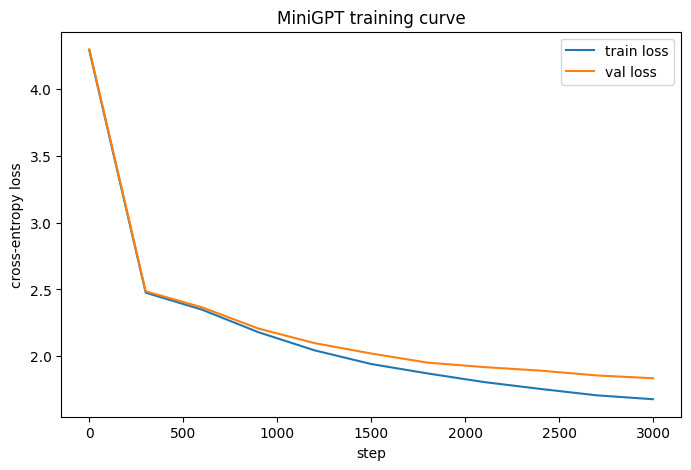

In [ ]:
import matplotlib.pyplot as plt

steps = [x['step'] for x in train_history]
train_losses = [x['train_loss'] for x in train_history]
val_losses = [x['val_loss'] for x in train_history]

plt.figure(figsize=(8, 5))
plt.plot(steps, train_losses, label='train loss')
plt.plot(steps, val_losses, label='val loss')
plt.xlabel('step')
plt.ylabel('cross-entropy loss')
plt.title('MiniGPT training curve')
plt.legend()
plt.show()


## 12. Prompting và generation

Ta thử 3 cách decode:

1. **Greedy**: luôn chọn token có xác suất cao nhất  
2. **Temperature sampling**: điều chỉnh độ ngẫu nhiên  
3. **Top-k sampling**: chỉ lấy mẫu trong top-k token có xác suất cao nhất


In [ ]:
def make_context(prompt: str):
    if len(prompt) == 0:
        return torch.zeros((1, 1), dtype=torch.long, device=device)
    return torch.tensor([encode(prompt)], dtype=torch.long, device=device)

prompt = 'To be, or not to be'
context = make_context(prompt)
print('prompt =', repr(prompt))


prompt = 'To be, or not to be'


In [ ]:
out_greedy = model.generate(context.clone(), max_new_tokens=300, greedy=True)
print('=== GREEDY ===')
print(decode(out_greedy[0].tolist()))


=== GREEDY ===
To be, or not to be the shall the so the some
The so the some the so the shall the so the so the son
The so the dear the so the so the so the so the so the so the some
The so the so the so the so the so the so the so the so the so the so the so the some
The so the so the so the so the so the so the so the so the so th


In [ ]:
out_temp = model.generate(
    context.clone(),
    max_new_tokens=300,
    greedy=False,
    temperature=0.8,
    top_k=None,
)
print('=== TEMPERATURE = 0.8 ===')
print(decode(out_temp[0].tolist()))


=== TEMPERATURE = 0.8 ===
To be, or not to be king plead the dided love hear good king our brock.

BUCKINGHAM:
May, the deye-bridlear are all bret heart
Look the hust marring prince to nathes honour both,
Thou shall me conte a greling as speak.

BUTUS:
I him God best night, but my and I brothing man'd surme no the
Them and the saven of then th


In [ ]:
out_topk = model.generate(
    context.clone(),
    max_new_tokens=300,
    greedy=False,
    temperature=0.9,
    top_k=20,
)
print('=== TEMPERATURE = 0.9, TOP-K = 20 ===')
print(decode(out_topk[0].tolist()))


=== TEMPERATURE = 0.9, TOP-K = 20 ===
To be, or not to bear as him.

WAMWINGBELA:
You will the chan be homanot my whom;
See and at her caring will house add hend, whene
That thou beading to hand the lamstain fair us the day,
Which inloans oftid for of one her some dend.

REMIO:
But you me. Lord the the and would as he leave steard,
I husse! be beselief: s


## 13. So sánh prompt khác nhau

Bạn có thể thay prompt để thấy rõ vai trò của **prompting**.

In [ ]:
test_prompts = [
    'KING RICHARD III:\n',
    'ROMEO:\n',
    'JULIET:\n',
]

for p in test_prompts:
    out = model.generate(make_context(p), max_new_tokens=180, temperature=0.8, top_k=20)
    print('=' * 80)
    print(decode(out[0].tolist()))
    print()


KING RICHARD III:
Who, like me he then the to here not;
And if thy may country nonger the
Shall our in the be must which you
do greate, thou sun our hope here still make pace
In well dead letty the 

ROMEO:
No do hour love than the will will for the lime.
Then have the reather men is me think's is dewby in.

BESCATENTIO:
So the keep senting of the ress friend, be whe as thy fair triet

JULIET:
Sway like, to know the me betchel it paciof
Thou countrester with he fact: the heave potain!
Shall best so froce to hone do strand paint;
That the har sould bese that, thy canly wo



## 14. Lưu checkpoint

Checkpoint này đủ để bạn nạp lại model và tiếp tục generate.

In [ ]:
ckpt_path = Path('mini_gpt_demo.pt')
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'stoi': stoi,
    'itos': itos,
    'config': {
        'batch_size': batch_size,
        'block_size': block_size,
        'n_embd': n_embd,
        'n_head': n_head,
        'n_layer': n_layer,
        'dropout': dropout,
        'vocab_size': vocab_size,
    },
    'train_history': train_history,
}, ckpt_path)

print('saved to', ckpt_path.resolve())


saved to /content/mini_gpt_demo.pt


## 15. Tổng kết: Notebook này map trực tiếp như sau:

| Nội dung chương 7 | Phần trong notebook |
|---|---|
| Language model | `get_batch()` + dự đoán token tiếp theo |
| Pretraining | training loop trên text thô |
| Decoder architecture | `MiniGPT` + `Block` + causal mask |
| Cross-entropy loss | `F.cross_entropy(...)` |
| Autoregressive generation | `model.generate(...)` |
| Prompting | phần `prompt` và `test_prompts` |
| Decoding | greedy / temperature / top-k |
| Evaluation | loss + perplexity |
